<a href="https://colab.research.google.com/github/aym-1/IT480-FA26/blob/main/Assignment2_TransferLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 2: Transfer Learning Across Two Datasets

**Name:** *Andrew Myshkevych*

**Prerequisite:** Transfer Learning lecture (frozen feature extraction)

This assignment uses frozen transfer learning, exactly what was covered in lecture: load a pretrained base, freeze it, add a new head, train only that. You'll do this twice, on two different datasets, and compare the results.

Data loading is provided for you below. Everything after that, building the model, training, evaluating, and reflecting, is yours to write, following the general instructions in each section.

**Submission:** GitHub repo URL and this notebook's URL on Canvas.

## Setup — Imports

In [12]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

---
# Part 1: Fire/Smoke Detection

## 1A — Load the Data

In [13]:
!pip install legacy-cgi --quiet
!pip install opendatasets --quiet

import opendatasets as od
od.download("https://www.kaggle.com/datasets/phylake1337/fire-dataset")

for root, dirs, files in os.walk("fire-dataset"):
    print(root, "->", dirs[:5], f"({len(files)} files)")

Skipping, found downloaded files in "./fire-dataset" (use force=True to force download)
fire-dataset -> ['fire_dataset'] (0 files)
fire-dataset/fire_dataset -> ['fire_images', 'non_fire_images'] (0 files)
fire-dataset/fire_dataset/fire_images -> [] (755 files)
fire-dataset/fire_dataset/non_fire_images -> [] (244 files)


In [14]:
data_dir_fire = "fire-dataset/fire_dataset"

img_size = (224, 224)
batch_size = 32

train_raw_fire = tf.keras.utils.image_dataset_from_directory(
    data_dir_fire, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="training", seed=42, shuffle=True
)

val_test_raw_fire = tf.keras.utils.image_dataset_from_directory(
    data_dir_fire, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="validation", seed=42, shuffle=True
)

val_test_batches_fire = tf.data.experimental.cardinality(val_test_raw_fire)
test_raw_fire = val_test_raw_fire.take(val_test_batches_fire // 2)
val_raw_fire = val_test_raw_fire.skip(val_test_batches_fire // 2)

class_names_fire = train_raw_fire.class_names
print("Class names:", class_names_fire)

Found 999 files belonging to 2 classes.
Using 700 files for training.
Found 999 files belonging to 2 classes.
Using 299 files for validation.
Class names: ['fire_images', 'non_fire_images']


## 1B — Inspect the Data

Before doing anything else, take a real look at what you loaded. How many images does each class have? Is there anything about the data itself that might affect how you should split it, or how you should interpret your model's results later?

Write whatever code you need to answer this for yourself.

fire_images        755
non_fire_images    244
dtype: int64
Always Fire Baseline: 75.58%


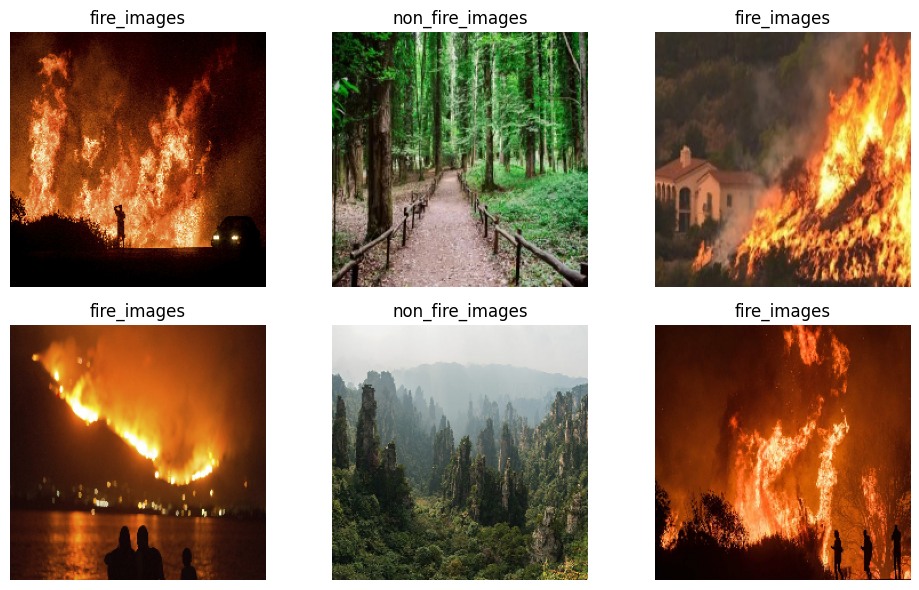

In [15]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt


fire_counts = pd.Series({name: sum(p.suffix.lower() in ('.jpg', ',jpeg', '.png', '.bmp', '.gif')
                                for p in (Path(data_dir_fire) / name).iterdir())
                          for name in class_names_fire})

print(fire_counts)
print("Always Fire Baseline:", f'{fire_counts["fire_images"] / fire_counts.sum():.2%}')

images, labels = next(iter(train_raw_fire))
plt.figure(figsize=(10, 6))
for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names_fire[int(labels[i])])
    plt.axis("off")
plt.tight_layout()
plt.show()

*What did you notice about this dataset? Does it change how you'll approach the next steps?*



## 1C — Build a Frozen Transfer Learning Model

Using MobileNetV2 as your pretrained base:
- Freeze the base model entirely
- Add a new output layer appropriate for this task (think about how many classes you're predicting, and what that means for your output layer's size, activation, and loss function)
- Remember the pattern from lecture for how the base model should be called

Preprocess your data (`train_raw_fire`, `val_raw_fire`, `test_raw_fire`) using MobileNetV2's expected preprocessing before building your model.

In [16]:
# Preprocess the data here

train_fire = train_raw_fire.map(lambda x, y: (preprocess_input(x), y)).prefetch(tf.data.AUTOTUNE)
test_fire = test_raw_fire.map(lambda x, y: (preprocess_input(x), y)).prefetch(tf.data.AUTOTUNE)
val_fire = val_raw_fire.map(lambda x, y: (preprocess_input(x), y)).prefetch(tf.data.AUTOTUNE)

In [22]:
# Build your model here

base_fire = MobileNetV2(include_top=False, weights='imagenet', input_shape=img_size + (3,))
base_fire.trainable=False
inputs = tf.keras.Input(shape=img_size + (3,))

x = base_fire(inputs, training=False)
x = GlobalAveragePooling2D()(x)
outputs = Dense(1, activation='sigmoid')(x)

model_fire = Model(inputs, outputs)

In [25]:
# Compile your model here

model_fire.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_fire.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 1D — Train and Evaluate

In [26]:
# Train your model here

model_fire.fit(train_fire, validation_data=val_fire, epochs=10)

Epoch 1/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 63s 3s/step - accuracy: 0.8229 - loss: 0.3723 - val_accuracy: 0.9353 - val_loss: 0.2040
Epoch 2/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 62s 3s/step - accuracy: 0.9571 - loss: 0.1489 - val_accuracy: 0.9640 - val_loss: 0.1273
Epoch 3/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 87s 4s/step - accuracy: 0.9657 - loss: 0.1052 - val_accuracy: 0.9640 - val_loss: 0.0939
Epoch 4/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 84s 4s/step - accuracy: 0.9743 - loss: 0.0858 - val_accuracy: 0.9712 - val_loss: 0.0859
Epoch 5/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 64s 3s/step - accuracy: 0.9814 - loss: 0.0738 - val_accuracy: 0.9784 - val_loss: 0.0677
Epoch 6/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 84s 4s/step - accuracy: 0.9871 - loss: 0.0642 - val_accuracy: 0.9640 - val_loss: 0.0807
Epoch 7/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 53s 2s/step - accuracy: 0.9871 - loss: 0.0581 - val_accuracy: 0.9568 - val_loss: 0.0707
Epoch 8/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 50s 2s/step - accuracy: 0.9929 - loss: 0.0518 - val_accuracy: 0.9640 - val_loss:

In [27]:
# Report validation and test accuracy here

_, val_acc = model_fire.evaluate(val_fire, verbose=0)
_, test_acc = model_fire.evaluate(test_fire, verbose=0)

print(f'Validation Accuracy: {val_acc:.2%}')
print(f'Test Accuracy: {test_acc:.2%}')

Validation Accuracy: 97.84%
Test Accuracy: 97.50%


## 1E — Confusion Matrix and Discussion

Build a confusion matrix for your model's test set predictions.

**Answer:** In this context, is a false negative (missing a real fire) or a false positive (a false alarm) more costly? How might that change the decision threshold you'd actually use in practice, rather than the default 0.5?

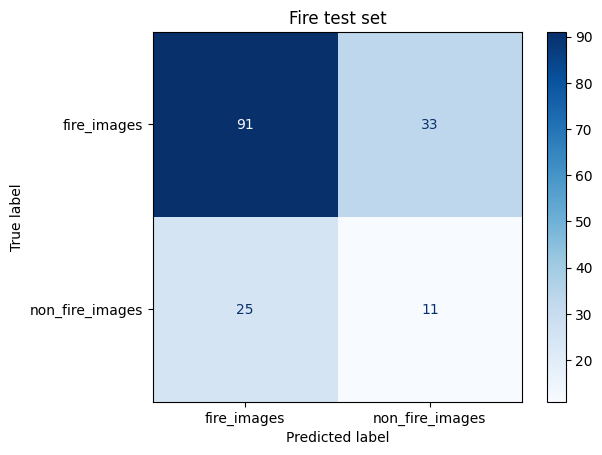

Missed Fires: 25
False Alarms: 33


In [29]:
# Build your confusion matrix here

y_true_fire = np.concatenate([y.numpy() for _, y in test_fire])
fire_probs = model_fire.predict(test_fire, verbose=0).ravel()
y_pred_fire = (fire_probs >= 0.5).astype(int)

cm_fire = confusion_matrix(y_true_fire, y_pred_fire, labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm_fire, display_labels=class_names_fire)
disp.plot(cmap='Blues')
plt.title("Fire test set")
plt.show()
print("Missed Fires:", cm_fire[1, 0])
print("False Alarms:", cm_fire[0, 1])

[link text](https://)A false negative is more costly due to a missed fire could cause injuries or property damage, while a false alarm usually causes an unnecessary inspection. I would consider lowering the threshold from 0.5 to 0.3 to catch more fires, accpeting more false alarms. I would choose the threshold using validation data and the accetable false-alarm rate, then evaluate it on the test set.





---
# Part 2: Satellite Land-Use Classification (EuroSAT)

## 2A — Load the Data

In [5]:
import os

!wget -q "https://zenodo.org/records/7711810/files/EuroSAT_RGB.zip?download=1" -O EuroSAT_RGB.zip
!unzip -qo EuroSAT_RGB.zip -d eurosat_data

data_dir_sat = "eurosat_data/EuroSAT_RGB"
print(os.listdir(data_dir_sat))

['PermanentCrop', 'Highway', 'Industrial', 'River', 'AnnualCrop', 'Pasture', 'HerbaceousVegetation', 'Residential', 'Forest', 'SeaLake']


In [13]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model

img_size = (224, 224)
batch_size = 32

train_raw_sat = tf.keras.utils.image_dataset_from_directory(
    data_dir_sat, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="training", seed=42, shuffle=True
)

val_test_raw_sat = tf.keras.utils.image_dataset_from_directory(
    data_dir_sat, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="validation", seed=42, shuffle=True
)

val_test_batches_sat = tf.data.experimental.cardinality(val_test_raw_sat)
test_raw_sat = val_test_raw_sat.take(val_test_batches_sat // 2)
val_raw_sat = val_test_raw_sat.skip(val_test_batches_sat // 2)

class_names_sat = train_raw_sat.class_names
print("Class names:", class_names_sat)

Found 27000 files belonging to 10 classes.
Using 18900 files for training.
Found 27000 files belonging to 10 classes.
Using 8100 files for validation.
Class names: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


## 2B — Build a Frozen Transfer Learning Model

Same overall pattern as Part 1, but look closely at what's different about this task before you build your output layer, activation, and loss function.

Preprocess `train_raw_sat`, `val_raw_sat`, and `test_raw_sat` first.

In [14]:
# Preprocess the data here
train_sat = train_raw_sat.map(lambda x, y: (preprocess_input(x), y)).prefetch(tf.data.AUTOTUNE)
test_sat = test_raw_sat.map(lambda x, y: (preprocess_input(x), y)).prefetch(tf.data.AUTOTUNE)
val_sat = val_raw_sat.map(lambda x, y: (preprocess_input(x), y)).prefetch(tf.data.AUTOTUNE)


In [15]:
# Build your model here
base_sat = MobileNetV2(include_top=False, weights='imagenet', input_shape=(224, 224, 3))
base_sat.trainable=False

inputs = tf.keras.Input(shape=(224, 224, 3))
x = base_sat(inputs, training=False)
x = GlobalAveragePooling2D()(x)
outputs = Dense(len(class_names_sat), activation='softmax')(x)

model_sat = Model(inputs, outputs)

In [16]:
# Compile your model here

model_sat.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_sat.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,270,794 (8.66 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 2C — Train and Evaluate

In [17]:
# Train your model here

model_sat.fit(train_sat, validation_data=val_sat, epochs=3)

Epoch 1/3
591/591 ━━━━━━━━━━━━━━━━━━━━ 1012s 2s/step - accuracy: 0.8772 - loss: 0.3715 - val_accuracy: 0.9279 - val_loss: 0.2197
Epoch 2/3
591/591 ━━━━━━━━━━━━━━━━━━━━ 954s 2s/step - accuracy: 0.9348 - loss: 0.1951 - val_accuracy: 0.9413 - val_loss: 0.1898
Epoch 3/3
591/591 ━━━━━━━━━━━━━━━━━━━━ 969s 2s/step - accuracy: 0.9465 - loss: 0.1591 - val_accuracy: 0.9376 - val_loss: 0.1889


In [18]:
# Report validation and test accuracy here

_, val_acc = model_sat.evaluate(val_sat, verbose=0)
_, test_acc = model_sat.evaluate(test_sat, verbose=0)

print(f'Validation Accuracy: {val_acc:.2%}')
print(f'Test Accuracy: {test_acc:.2%}')

Validation Accuracy: 93.81%
Test Accuracy: 93.09%


## 2D — Confusion Matrix and Discussion

Build a confusion matrix for your model's test set predictions.

**Answer:** Which land-use classes get confused most often? Does that make visual sense to you?

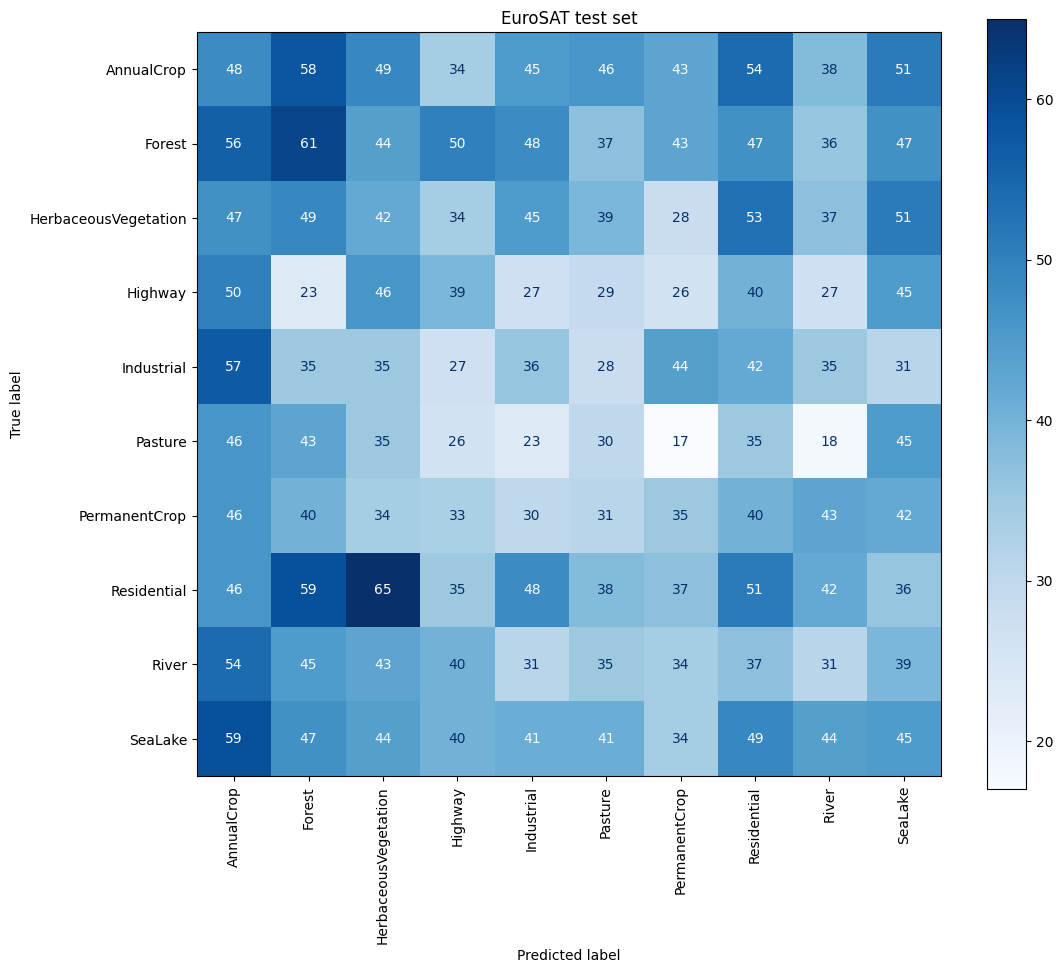

Most confused pairs: HerbaceousVegetation and Residential
Total mistakes between them: 118


In [21]:
# Build your confusion matrix here
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_true_sat = np.concatenate([y.numpy() for _, y in test_sat])
y_pred_sat = model_sat.predict(test_sat, verbose=0).argmax(axis=1)

cm_sat = confusion_matrix(y_true_sat, y_pred_sat, labels=range(len(class_names_sat)))
fig, ax = plt.subplots(figsize=(12, 10))
ConfusionMatrixDisplay(cm_sat, display_labels=class_names_sat).plot(cmap='Blues', ax=ax, xticks_rotation=90)
plt.title("EuroSAT test set")
plt.tight_layout
plt.show()

pair_errors = cm_sat + cm_sat.T
np.fill_diagonal(pair_errors, 0)
pair_a, pair_b = np.unravel_index(pair_errors.argmax(), pair_errors.shape)
print("Most confused pairs:", class_names_sat[pair_a], 'and', class_names_sat[pair_b])
print('Total mistakes between them:', pair_errors[pair_a, pair_b])

[link text](https://)*Your answer:* The classes that are confused most often are the Herbaceous Vegetation and RTesid4ential, with 118 total mistakes between them. That does make sense due to the satellite images of residential areas do contain a lot of grass, trees, yards, and other vegetation, so some resdential scenes can look similar to areas dominated by the herbaceous vegetation




---
# Part 3: Compare the Two Domains

Fill in your own results:

| | Fire/Smoke | EuroSAT |
|---|---|---|
| Validation Accuracy | 97.84%| 93.81%|
| Test Accuracy | 97.50%| 93.09%|

**Answer:**
1. MobileNetV2 was originally trained on ImageNet, ordinary ground-level photos of everyday objects. Which of your two datasets do you think is the closer match to that original training, and which is the bigger mismatch? Use your actual results as evidence.
2. For each dataset, do you think there's room for improvement if you could adjust part of the pretrained model itself, rather than just the new layer on top? Would you expect that to matter more for one dataset than the other? Why?



```
# This is formatted as code
```

*Your answers:*
1. The Fire/Smoke dataset is the closer match to MobileNetV2's original ImageNet training because both containb more typical ground-level photographic images. The EuroSAT dataset is a bigger mismatch because it contains satellite imageryu taken from above, which looks very different from normal ImageNet photos. My results support this because the Fire/Smoke model achieved 97.50% test accuracy, while the EuroSAT model achieved 93.09% test accuracy.

2. I think both datasets could improve if some of the pretrained MobileNetV2 layers were unfrozen and fine-tuned. I would expect fine-tuning to matter more for EuroSAT because satellite images are more different from the ground-level images MobileNetV2 originally learned from. Fine-tuning could allow the model to adjust some of its learned features to better recognize patterns such as land use, vegetation, roads, and buildings from an overhead view. The Fire/Smoke model may still improve from fine-tuning, but its already high accuracy suggets the frozen ImageNet featrures transfer well to that task.



---
# Part 4: Reflection

Answer in 4 to 6 sentences:

1. Did anything about the Fire dataset's composition affect how you approached splitting or evaluating it? Explain.
2. What's the actual difference between the output layer, activation, and loss function you used in Part 1 versus Part 2? Why does that difference exist?
3. Based on your results, does a pretrained model's usefulness depend only on how good the model is, or also on how well its original training matches your task? Explain using your own two results as evidence.

*Your answers:*
1. The Fire dataset was unbalanced, with 755 fire images and 244 non-fire images, so I had to be careful when I had to intepret the acccuracy because just simply prediciting fire every time would already give about 75.58% accuracy. In Part 1, I used one output neuron with a sigmoid activiation and binary crossentropy because the fire task has two classes, while in Part 2 I used 10 output neurons with softmax and sparse categorical crossentropy because EuroSAT has 10 classes. The Pretrained model worked well on both datasets, but it performed better on the Fire dataset, with 97.50% test accuracy compared with 93.09% on EuroSAT. This means that a pretrained model's usefulness depends not only on the quality of the model, but also on how similar the new task is to the data it was originally trained on. Since EuroSAT satellite imagery is more different from ordinary ImageNet photos, its lower accuracy makes sense and suggests that fine-tuning could help more on that dataset.

---
## Done!

Save this notebook back to your GitHub fork, then submit your two links on Canvas.